In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import util.read_price as read_price

ip_prob  = read_price.read_ip_forecast(model="XGB",  kind="probabilistic", freq="15min")
ip_real = read_price.read_ip_real_prices(freq="15min", keep_extra_columns=False)["Price"]


C:\Users\mmascare\OneDrive - KU Leuven\Documents\Code\DA_Optimization\Data\IP_CET\IP_XGB.csv
C:\Users\mmascare\OneDrive - KU Leuven\Documents\Code\DA_Optimization\Data\IP_CET\IP_Real_Prices.csv


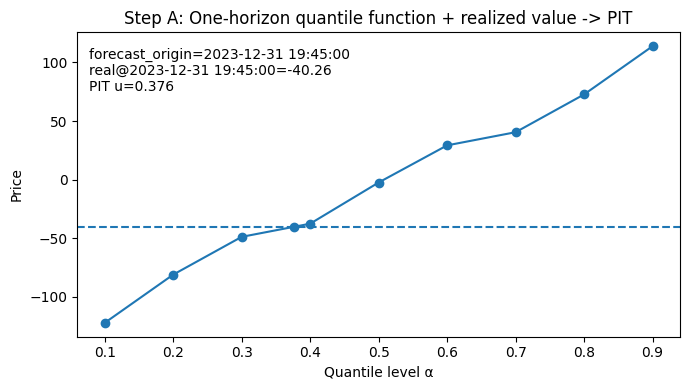

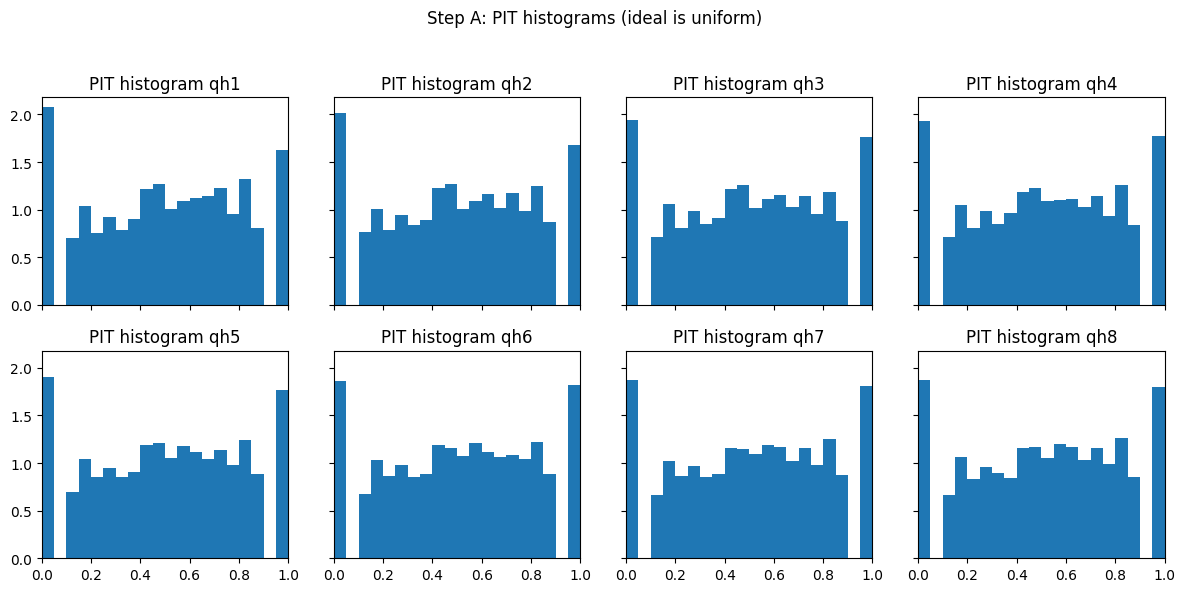

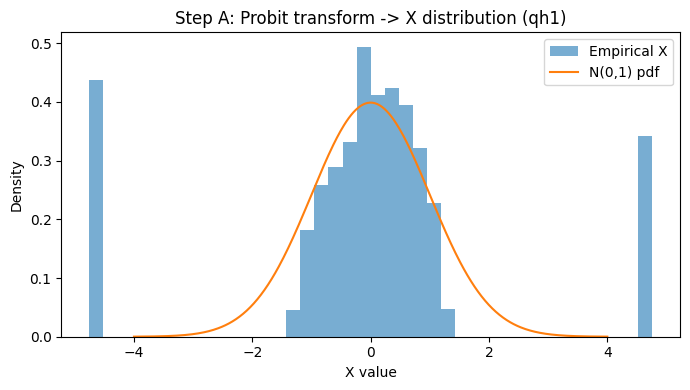

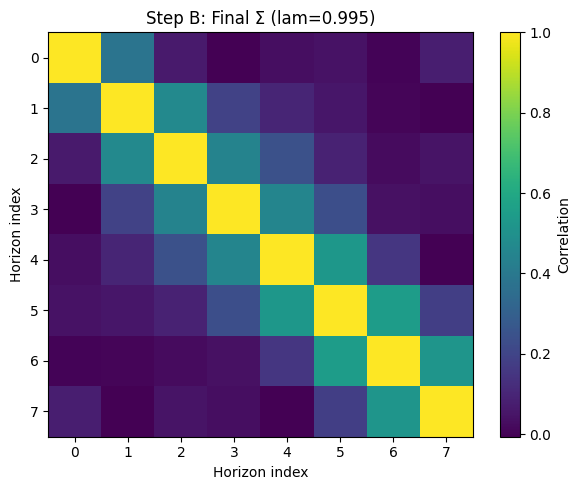

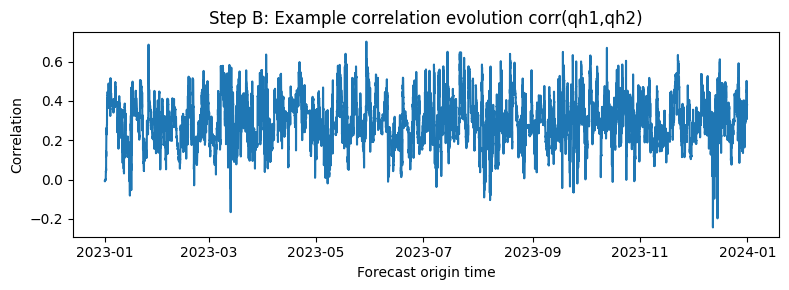

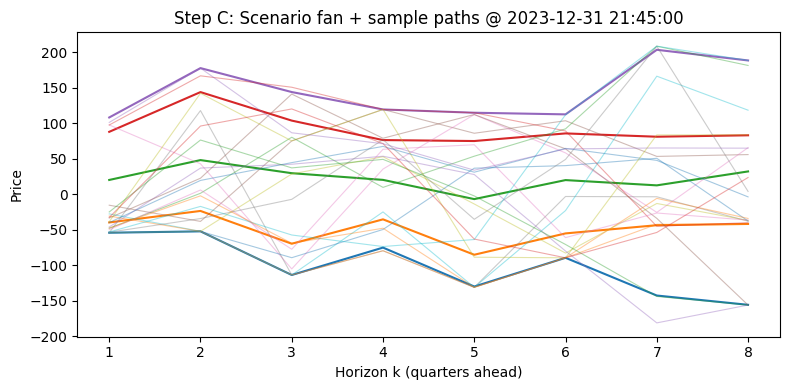

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Optional

# -----------------------------
# Plotting + methodology utilities
# -----------------------------

def _get_qcols(k, quantiles):
    return [f"qh{k}_q{q:.1f}" for q in quantiles]

def compute_gaussian_errors_with_pit(
    ip_det,
    ip_real,
    K=8,
    quantiles=np.arange(0.1, 1.0, 0.1),
    *,
    as_of: Optional[pd.Timestamp] = None,
    dt: pd.Timedelta = pd.Timedelta(minutes=15),
):
    """
    Convention (your clarified one):
      - At decision time t, you forecast qh1 for interval [t, t+dt).
      - Therefore, the realized price at timestamp t is NOT known at decision time t.
      - No-leakage requirement: when estimating PIT/X, only use forecast origins s such that
            s + (K-1)*dt < as_of
        i.e., the whole verification window is strictly in the past.

    Returns:
      X_df: DataFrame (index = forecast origin s) columns X_qh1..X_qhK
      U_df: DataFrame PIT values (index = s) columns U_qh1..U_qhK
    """
    ip_det = ip_det.sort_index()
    ip_real = ip_real.sort_index()

    # NEW: filter forecast origins to those fully verified strictly before "as_of"
    if as_of is not None:
        cutoff = pd.to_datetime(as_of) - K * dt  # strict: s + (K-1)dt < as_of  <=>  s <= as_of - K*dt
        ip_det = ip_det.loc[ip_det.index <= cutoff]

    X_rows, U_rows, idx = [], [], []

    for t in ip_det.index:
        x_t, u_t = [], []
        ok = True
        for k in range(1, K + 1):
            # verification timestamp for horizon k (qh1 verifies at t, qh2 at t+dt, ...)
            t_real = t + (k - 1) * dt
            if t_real not in ip_real.index:
                ok = False
                break

            p_real = float(ip_real.loc[t_real])
            q_vals = ip_det.loc[t, _get_qcols(k, quantiles)].values.astype(float)

            # enforce monotone quantiles
            q_vals_sorted = np.maximum.accumulate(q_vals)

            # PIT -> probit
            u = np.interp(p_real, q_vals_sorted, quantiles, left=0.0, right=1.0)#At which quantile level would the realized price fall, according to the forecasted distribution
            u = float(np.clip(u, 1e-6, 1 - 1e-6))
            x = float(norm.ppf(u))#The percent-point function (inverse CDF) of a standard normal distribution. x is a Gaussianized forecast error (probit function)

            u_t.append(u)
            x_t.append(x)

        if ok and len(x_t) == K:
            idx.append(t)
            U_rows.append(u_t)
            X_rows.append(x_t)

    col_u = [f"U_qh{k}" for k in range(1, K + 1)]
    col_x = [f"X_qh{k}" for k in range(1, K + 1)]
    U_df = pd.DataFrame(U_rows, index=pd.DatetimeIndex(idx), columns=col_u)
    X_df = pd.DataFrame(X_rows, index=pd.DatetimeIndex(idx), columns=col_x)
    return X_df, U_df

def estimate_covariance_path(X_df, lam=0.995):
    """
    Returns:
      Sigma_list: list of Sigma_t (correlation matrices) over time
      Sigma_final: final matrix
    """
    X = X_df.values
    K = X.shape[1]
    Sigma = np.eye(K)
    Sigma_list = []

    for xt in X:
        xt = xt.reshape(-1, 1)
        Sigma = lam * Sigma + (1 - lam) * (xt @ xt.T)#Exponentially Weighted Moving Average (EWMA). Recent observations matter more. (xt @ xt.T) rank-1 estimate

        # normalize to unit variance => correlation matrix
        std = np.sqrt(np.diag(Sigma))
        Sigma = Sigma / np.outer(std, std)# np.outer(std, std) Creates a matrix. Sigma / np.outer(std, std) is the definition of a correlation coefficient. This normalizes the matrix by forcing diagonal to 1 (because it will never be exacly one)

        Sigma_list.append(Sigma.copy())
    return Sigma_list, Sigma

def inverse_cdf_from_quantiles(u, quantiles, values):
    q_ext = np.concatenate(([0.0], quantiles, [1.0]))
    v_ext = np.concatenate(([values[0]], values, [values[-1]]))
    return np.interp(u, q_ext, v_ext)

def generate_scenarios_single_t(
    forecast_time,
    ip_det,
    Sigma,
    n_scenarios=500,
    K=8,
    quantiles=np.arange(0.1, 1.0, 0.1),
    seed=123,
):
     #(Gaussian → Uniform → Real values)
    rng = np.random.default_rng(seed)
    Xs = rng.multivariate_normal(mean=np.zeros(K), cov=Sigma, size=n_scenarios)#Instead of drawing each column independently this line draws them together, enforcing the dependence encoded in Sigma.
    Ys = norm.cdf(Xs) # It takes each number in Xs and replaces it by the probability of seeing a value smaller than it under a standard normal distribution. if x = 0.00 then norm.cdf(0.00) = 0.50 Half of the time, a standard normal variable is below 0.
    #Xs are Gaussian errors, Ys become uniform values. Although each value in Ys is uniform on its own, they are not independent, the dependence you learned in Sigma is preserved.
    #To sample from a distribution defined by quantiles, you must map it through the inverse CDF

    scenarios = np.zeros((n_scenarios, K))
    for k in range(1, K + 1):
        q_vals = ip_det.loc[forecast_time, _get_qcols(k, quantiles)].values.astype(float)
        q_vals = np.maximum.accumulate(q_vals)  # enforce monotone
        scenarios[:, k - 1] = [
            inverse_cdf_from_quantiles(Ys[i, k - 1], quantiles, q_vals) for i in range(n_scenarios)
        ]
    return Xs, Ys, scenarios




def plot_methodology(
    ip_det,
    ip_real,
    forecast_time=None,
    K=8,
    quantiles=np.arange(0.1, 1.0, 0.1),
    lam=0.995,
    n_scenarios=500,
):
    """
    End-to-end plots:
      1) For one horizon and one time: forecast quantiles + realized value, show PIT
      2) PIT histogram for each horizon
      3) X histogram vs N(0,1) for qh1
      4) Estimated Σ heatmap (final)
      5) Example scenarios fan chart for selected forecast_time

    IMPORTANT (no leakage):
      We estimate Sigma using only history strictly before forecast_time.
    """
    if forecast_time is None:
        forecast_time = ip_det.index[-1]

    DT = pd.Timedelta(minutes=15)

    # NEW: Compute PIT/X using only info strictly before forecast_time
    X_df, U_df = compute_gaussian_errors_with_pit(
        ip_det,
        ip_real,
        K=K,
        quantiles=quantiles,
        as_of=forecast_time,
        dt=DT,
    )

    if X_df.empty:
        raise ValueError(
            "Not enough fully-verified history before forecast_time to estimate Sigma. "
            "Try an earlier forecast_time or a shorter horizon K."
        )

    # 1) Single-time, single-horizon view: quantiles + realized
    # NOTE: for plotting calibration you need a time whose realization exists.
    # We use a time strictly in the past relative to forecast_time to avoid leakage here too.
    t_plot = X_df.index[-1]
    k_show = 1  # qh1 verifies at t_plot
    t_real = t_plot + (k_show - 1) * DT
    p_real = float(ip_real.loc[t_real]) if t_real in ip_real.index else np.nan

    q_vals = ip_det.loc[t_plot, _get_qcols(k_show, quantiles)].values.astype(float)
    q_vals = np.maximum.accumulate(q_vals)
    u = np.interp(p_real, q_vals, quantiles, left=0.0, right=1.0) if np.isfinite(p_real) else np.nan

    plt.figure(figsize=(7, 4))
    plt.plot(quantiles, q_vals, marker="o")
    if np.isfinite(p_real):
        plt.axhline(p_real, linestyle="--")
        plt.scatter([u], [p_real], zorder=5)
        plt.text(
            0.02,
            0.95,
            f"forecast_origin={t_plot}\nreal@{t_real}={p_real:.2f}\nPIT u={u:.3f}",
            transform=plt.gca().transAxes,
            va="top",
        )
    plt.xlabel("Quantile level α")
    plt.ylabel("Price")
    plt.title("Step A: One-horizon quantile function + realized value -> PIT")
    plt.tight_layout()
    plt.show()

    # 2) PIT histograms
    fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=True, sharey=True)
    axes = axes.ravel()
    for k in range(1, K + 1):
        ax = axes[k - 1]
        ax.hist(U_df[f"U_qh{k}"].values, bins=20, density=True)
        ax.set_title(f"PIT histogram qh{k}")
        ax.set_xlim(0, 1)
    fig.suptitle("Step A: PIT histograms (ideal is uniform)")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    # 3) Gaussianized errors X hist vs N(0,1)
    kx = 1
    xvals = X_df[f"X_qh{kx}"].values
    plt.figure(figsize=(7, 4))
    plt.hist(xvals, bins=40, density=True, alpha=0.6, label="Empirical X")
    grid = np.linspace(-4, 4, 400)
    plt.plot(grid, norm.pdf(grid), label="N(0,1) pdf")
    plt.title(f"Step A: Probit transform -> X distribution (qh{kx})")
    plt.xlabel("X value")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) Recursive covariance estimation and final Σ heatmap
    Sigma_list, Sigma_final = estimate_covariance_path(X_df, lam=lam)
    plt.figure(figsize=(6, 5))
    plt.imshow(Sigma_final, aspect="auto")
    plt.colorbar(label="Correlation")
    plt.title(f"Step B: Final Σ (lam={lam})")
    plt.xlabel("Horizon index")
    plt.ylabel("Horizon index")
    plt.tight_layout()
    plt.show()

    # Optional: show Σ evolution for corr(qh1,qh2)
    corr12 = [S[0, 1] for S in Sigma_list]
    plt.figure(figsize=(8, 3))
    plt.plot(X_df.index, corr12)
    plt.title("Step B: Example correlation evolution corr(qh1,qh2)")
    plt.xlabel("Forecast origin time")
    plt.ylabel("Correlation")
    plt.tight_layout()
    plt.show()

    # 5) Scenario generation fan chart at forecast_time using Sigma_final estimated from past-only data
    Xs, Ys, scenarios = generate_scenarios_single_t(
        forecast_time, ip_det, Sigma_final, n_scenarios=n_scenarios, K=K, quantiles=quantiles, seed=123
    )
    horizons = np.arange(1, K + 1)
    plt.figure(figsize=(8, 4))
    for a in [0.1, 0.25, 0.5, 0.75, 0.9]:
        plt.plot(horizons, np.quantile(scenarios, a, axis=0), label=f"scen q={a}")
    for i in range(min(20, n_scenarios)):
        plt.plot(horizons, scenarios[i], linewidth=0.8, alpha=0.4)
    plt.title(f"Step C: Scenario fan + sample paths @ {forecast_time}")
    plt.xlabel("Horizon k (quarters ahead)")
    plt.ylabel("Price")
    plt.tight_layout()
    plt.show()

    return X_df, U_df, Sigma_final, scenarios

# Example run:
X_df, U_df, Sigma_final, scenarios = plot_methodology(ip_prob, ip_real, forecast_time=ip_prob.index[-1])


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Optional

def _heatmap(mat, title="", xlabel="", ylabel="", ticklabels=None):
    plt.figure(figsize=(6, 5))
    plt.imshow(mat, aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if ticklabels is not None:
        plt.xticks(range(len(ticklabels)), ticklabels, rotation=0)
        plt.yticks(range(len(ticklabels)), ticklabels, rotation=0)
    plt.tight_layout()
    plt.show()

def _hist_grid(samples, title_prefix, bins=40, ncols=4):
    K = samples.shape[1]
    nrows = int(np.ceil(K / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=False, sharey=False)
    axes = np.array(axes).ravel()
    for k in range(K):
        ax = axes[k]
        ax.hist(samples[:, k], bins=bins, density=True)
        ax.set_title(f"{title_prefix} dim {k+1}")
    for j in range(K, len(axes)):
        axes[j].axis("off")
    fig.tight_layout()
    plt.show()

def _pair_scatter(samples, i=0, j=1, title="", xlim=None, ylim=None):
    plt.figure(figsize=(5, 5))
    plt.scatter(samples[:, i], samples[:, j], s=8, alpha=0.35)
    plt.title(title)
    plt.xlabel(f"dim {i+1}")
    plt.ylabel(f"dim {j+1}")
    if xlim is not None: plt.xlim(*xlim)
    if ylim is not None: plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

def _corr_matrix(samples, method="pearson"):
    df = pd.DataFrame(samples, columns=[f"d{k+1}" for k in range(samples.shape[1])])
    return df.corr(method=method).values

def _show_step_banner(txt):
    plt.figure(figsize=(10, 0.8))
    plt.axis("off")
    plt.text(0.01, 0.5, txt, fontsize=12, va="center")
    plt.tight_layout()
    plt.show()


def generate_scenarios_single_t_debug(
    forecast_time,
    ip_det,
    Sigma,
    n_scenarios=500,
    K=8,
    quantiles=np.arange(0.1, 1.0, 0.1),
    seed=123,
    pair=(0, 1),          # which two horizons to show in scatter plots
    show=True,
):
    """
    Debuggable version of:
      Xs ~ N(0, Sigma)
      Ys = Phi(Xs)
      scenarios_k = F_k^{-1}(Ys_k) using forecast quantiles for each horizon

    Produces plots for each step if show=True.
    """
    rng = np.random.default_rng(seed)

    if show:
        _show_step_banner("Step C0 — Input dependence structure (Sigma)")
        _heatmap(Sigma, title="Sigma (correlation in Gaussian space)", xlabel="Horizon", ylabel="Horizon",
                 ticklabels=[f"qh{k}" for k in range(1, K+1)])

    # --------------------------
    # Step C1: Gaussian sampling
    # --------------------------
    Xs = rng.multivariate_normal(mean=np.zeros(K), cov=Sigma, size=n_scenarios)

    if show:
        _show_step_banner("Step C1 — Sample Xs ~ N(0, Sigma)")
        _hist_grid(Xs, "Xs (Gaussian)", bins=40)
        _pair_scatter(
            Xs, i=pair[0], j=pair[1],
            title=f"Xs pair scatter (qh{pair[0]+1} vs qh{pair[1]+1})\nDependence should match Sigma"
        )
        _heatmap(_corr_matrix(Xs, method="pearson"),
                 title="Empirical Pearson corr of Xs (should resemble Sigma)",
                 xlabel="Horizon", ylabel="Horizon",
                 ticklabels=[f"qh{k}" for k in range(1, K+1)])

    # --------------------------
    # Step C2: Gaussian -> Uniform
    # --------------------------
    Ys = norm.cdf(Xs)

    if show:
        _show_step_banner("Step C2 — Transform Ys = Phi(Xs) (Gaussian copula -> Uniform marginals)")
        _hist_grid(Ys, "Ys (Uniform)", bins=30)
        # Uniform dependence is not well represented by Pearson; use Spearman
        _pair_scatter(
            Ys, i=pair[0], j=pair[1],
            title=f"Ys pair scatter (qh{pair[0]+1} vs qh{pair[1]+1})\nUniform marginals, dependent copula"
        )
        _heatmap(_corr_matrix(Ys, method="spearman"),
                 title="Empirical Spearman corr of Ys (rank dependence)",
                 xlabel="Horizon", ylabel="Horizon",
                 ticklabels=[f"qh{k}" for k in range(1, K+1)])

    # --------------------------
    # Step C3: Uniform -> price scenarios via inverse CDF (from quantiles)
    # --------------------------
    scenarios = np.zeros((n_scenarios, K))

    def _get_qcols(k, quantiles):
        return [f"qh{k}_q{q:.1f}" for q in quantiles]

    def inverse_cdf_from_quantiles(u, quantiles, values):
        q_ext = np.concatenate(([0.0], quantiles, [1.0]))
        v_ext = np.concatenate(([values[0]], values, [values[-1]]))
        return np.interp(u, q_ext, v_ext)

    if show:
        _show_step_banner("Step C3 — Map each Ys[:,k] through inverse CDF defined by forecast quantiles")

    # Show the quantile function (value vs alpha) for a selected horizon
    k_show = pair[0] + 1
    q_vals_show = ip_det.loc[forecast_time, _get_qcols(k_show, quantiles)].values.astype(float)
    q_vals_show = np.maximum.accumulate(q_vals_show)

    if show:
        plt.figure(figsize=(7, 4))
        plt.plot(quantiles, q_vals_show, marker="o")
        plt.title(f"Forecast quantile function at {forecast_time}\nHorizon qh{k_show}")
        plt.xlabel("Quantile level α")
        plt.ylabel("Price")
        plt.tight_layout()
        plt.show()

        # Show how uniform draws map to prices for this horizon
        u_draws = Ys[:, k_show - 1]
        mapped = np.array([inverse_cdf_from_quantiles(u, quantiles, q_vals_show) for u in u_draws])
        plt.figure(figsize=(7, 4))
        plt.scatter(u_draws[:300], mapped[:300], s=10, alpha=0.4)
        plt.title(f"Inverse-CDF mapping (first 300 scenarios)\nqh{k_show}: u -> price")
        plt.xlabel("u ~ Uniform(0,1)")
        plt.ylabel("price")
        plt.tight_layout()
        plt.show()

    for k in range(1, K + 1):
        q_vals = ip_det.loc[forecast_time, _get_qcols(k, quantiles)].values.astype(float)
        q_vals = np.maximum.accumulate(q_vals)
        scenarios[:, k - 1] = [inverse_cdf_from_quantiles(Ys[i, k - 1], quantiles, q_vals)
                              for i in range(n_scenarios)]

    if show:
        _show_step_banner("Step C4 — Resulting price scenarios (marginals + dependence in price space)")
        _hist_grid(scenarios, "Scenario prices", bins=40)
        _pair_scatter(
            scenarios, i=pair[0], j=pair[1],
            title=f"Scenario price scatter (qh{pair[0]+1} vs qh{pair[1]+1})"
        )
        _heatmap(_corr_matrix(scenarios, method="spearman"),
                 title="Spearman corr of scenario prices (rank dependence in value space)",
                 xlabel="Horizon", ylabel="Horizon",
                 ticklabels=[f"qh{k}" for k in range(1, K+1)])

        # Fan chart across horizons
        horizons = np.arange(1, K + 1)
        plt.figure(figsize=(8, 4))
        for a in [0.1, 0.25, 0.5, 0.75, 0.9]:
            plt.plot(horizons, np.quantile(scenarios, a, axis=0), label=f"scen q={a}")
        for i in range(min(20, n_scenarios)):
            plt.plot(horizons, scenarios[i], linewidth=0.8, alpha=0.35)
        plt.title(f"Scenario fan chart @ {forecast_time}")
        plt.xlabel("Horizon k (quarters ahead)")
        plt.ylabel("Price")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return Xs, Ys, scenarios


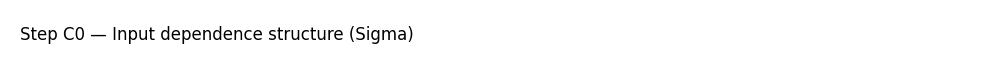

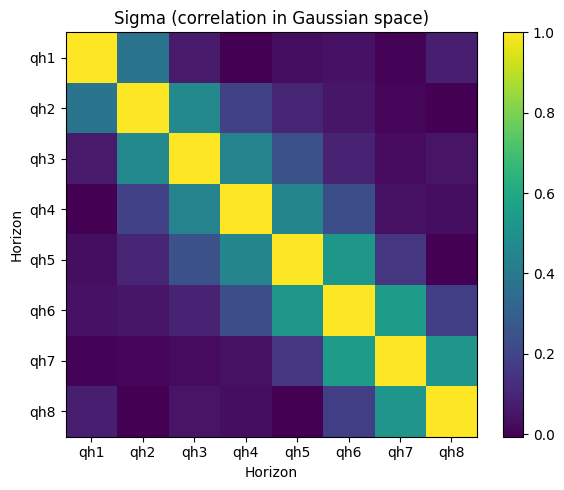

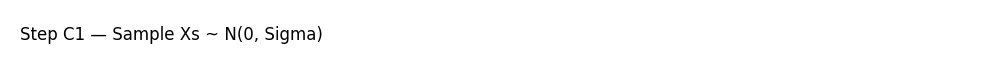

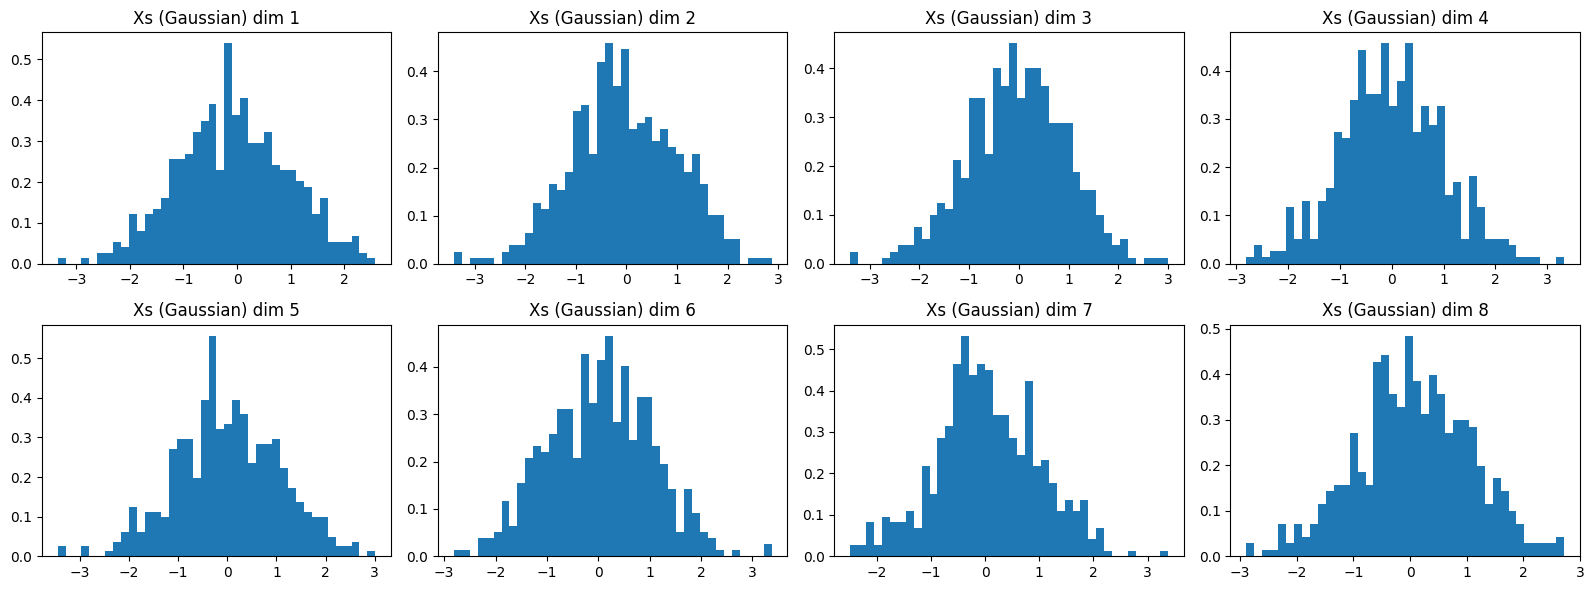

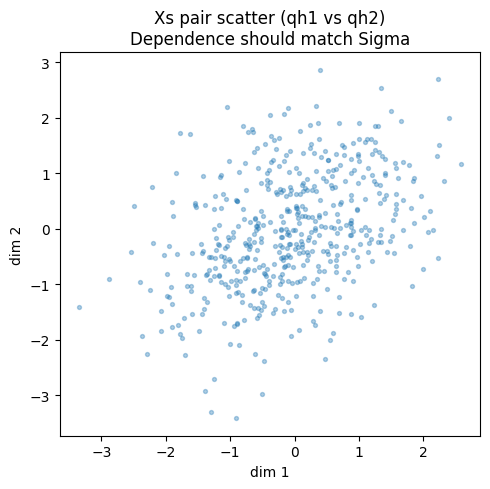

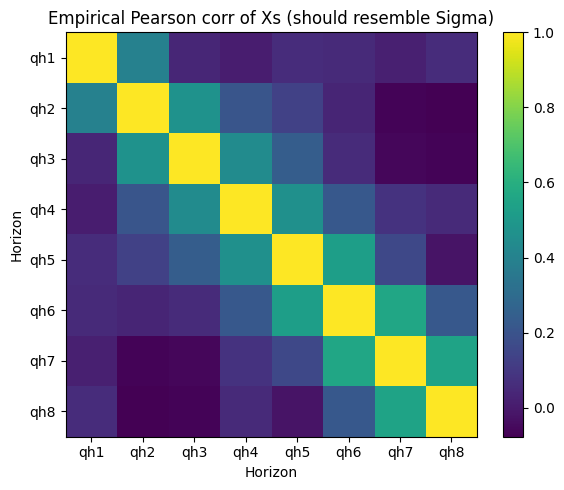

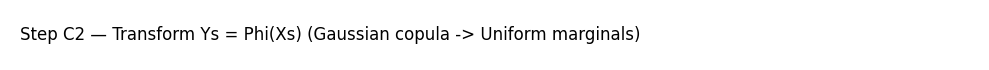

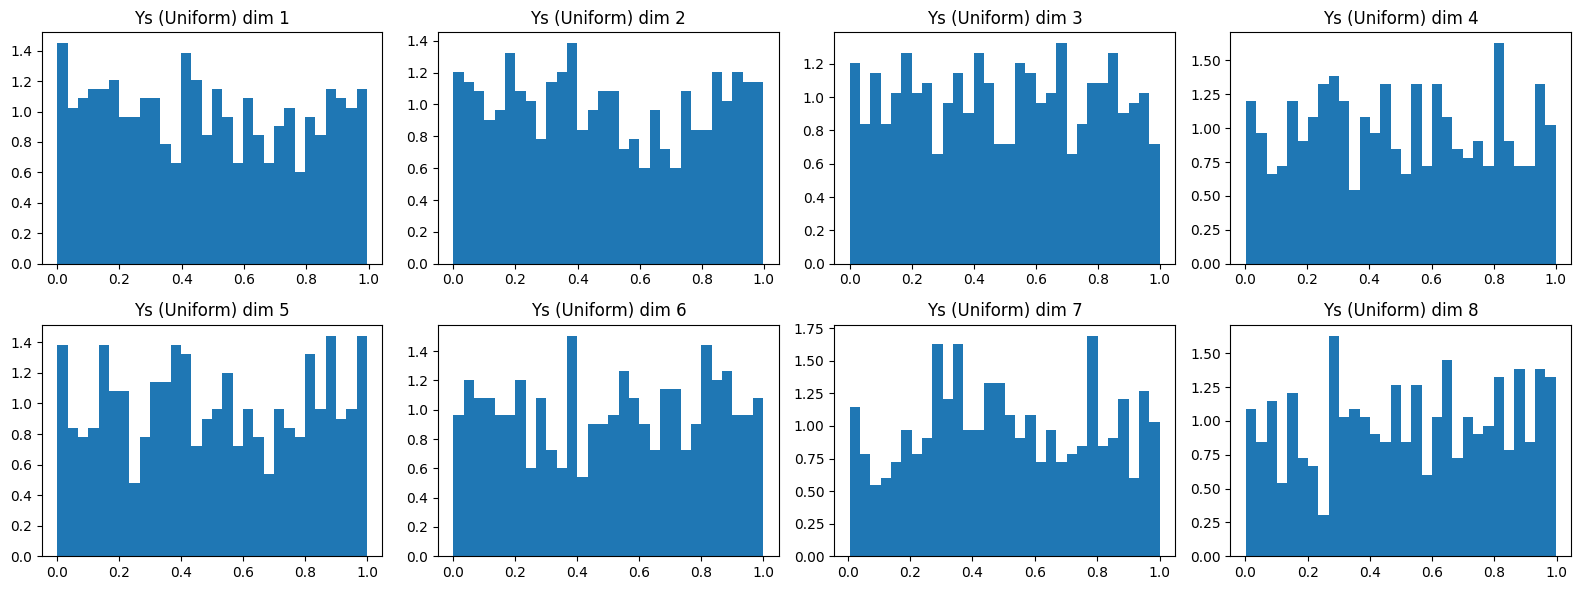

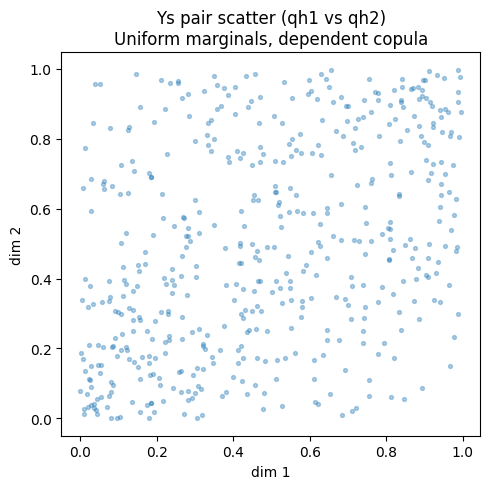

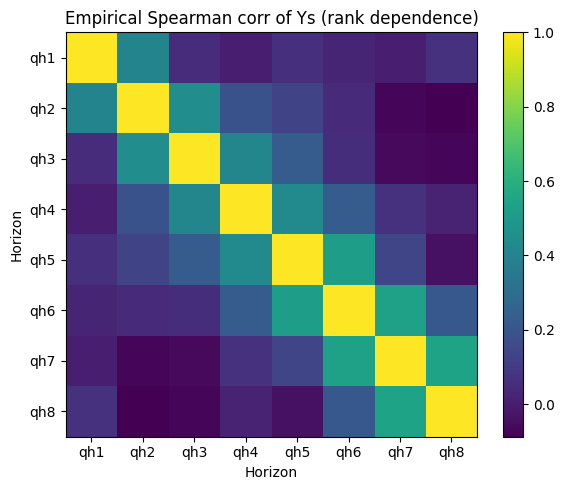

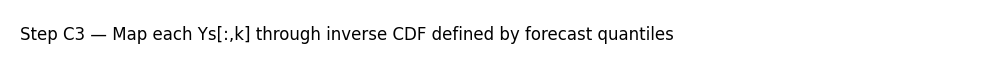

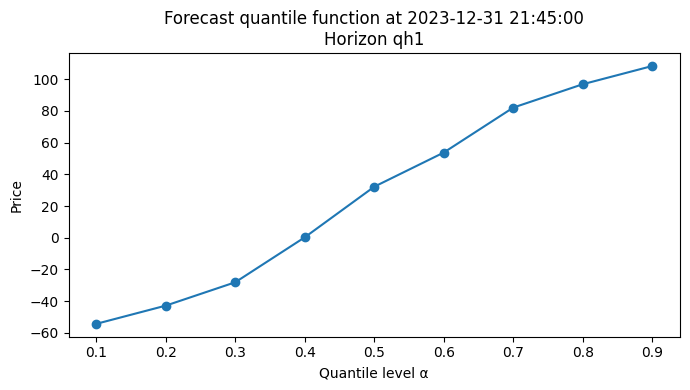

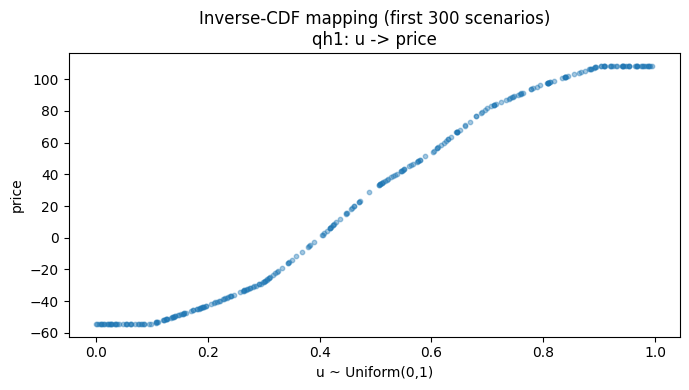

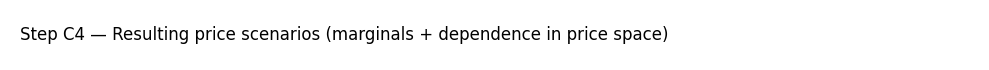

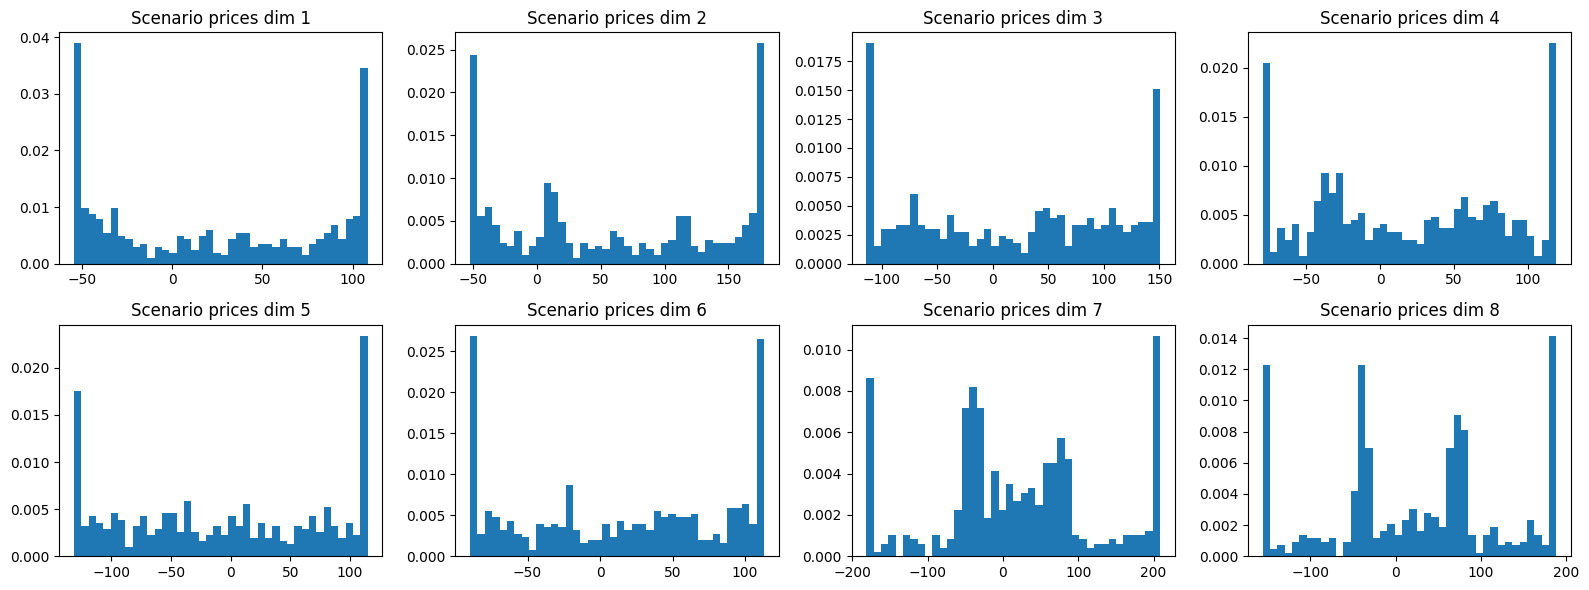

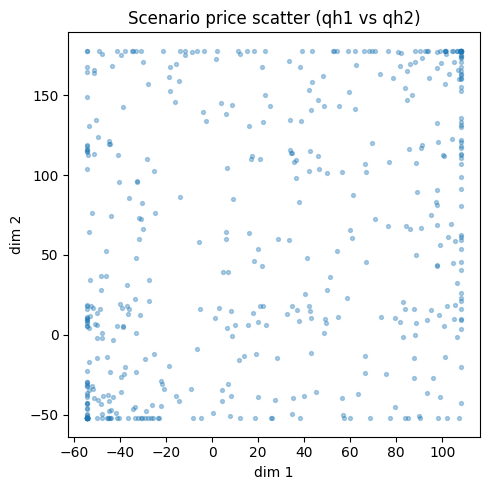

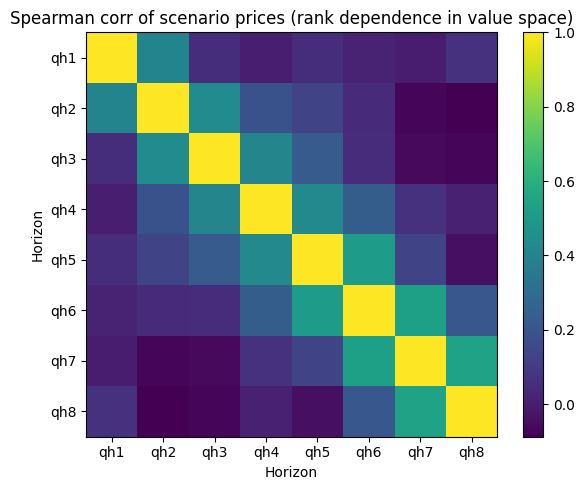

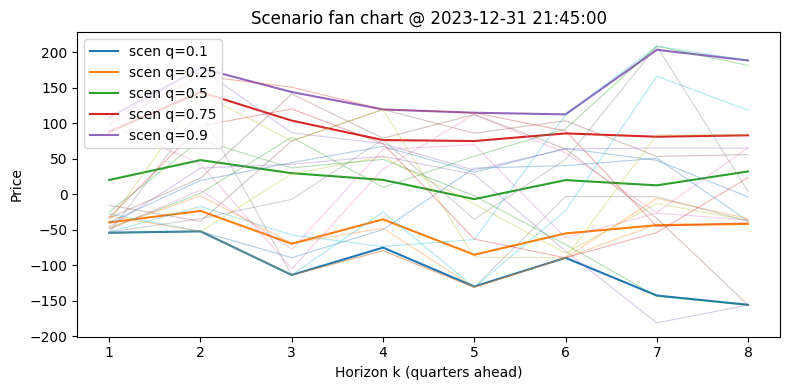

In [7]:
forecast_time = ip_prob.index[-1]   # or any time you want
Xs, Ys, scenarios = generate_scenarios_single_t_debug(
    forecast_time=forecast_time,
    ip_det=ip_prob,
    Sigma=Sigma_final,
    n_scenarios=500,
    K=8,
    quantiles=np.arange(0.1, 1.0, 0.1),
    seed=123,
    pair=(0, 1),   # show horizon 1 vs 2 in scatters
    show=True,
)
